## The Streamfunction–Vorticity Poisson Equation

We consider a steady-state 2D incompressible flow described using the streamfunction–vorticity formulation. The governing PDE is

$$
-\nabla^2 \psi(x,y) = \omega(x,y), \quad x \in \Omega
$$

where $\omega(x,y)$ is the vorticity field and $\psi(x,y)$ is the streamfunction.

### (1.1) Neural Operator learning problem

The problem is defined in $\Omega = [0,1]^2$ with the following boundary conditions:

- **All boundaries**: $\psi = 0$ (Dirichlet boundary condition)

We are interested in learning the mapping from the vorticity field $\omega(x,y)$ to the streamfunction $\psi(x,y)$, i.e.,

$$
\mathcal{G}: \omega(x,y) \rightarrow \psi(x,y)
$$

## (2) The Physics-informed DeepOnet

In [1]:
import sys
print(sys.executable)

c:\Users\samin\miniconda3\envs\pideeponet\python.exe


In [2]:
import torch

print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5070


In [2]:
import sys 
sys.path.append("../..") 

import numpy as np
import h5py
import torch 
import matplotlib.pyplot as plt

def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

# Set random seed
random_seed = 1234
setup_seed(random_seed)

if torch.cuda.is_available():
    device = 'cuda:0'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
    
dtype = torch.float32

# ============================================================
# Problem name
# ============================================================
problem_name = 'vorticity_streamfunction_2d'
tag = 'vorticity'

# ============================================================
# Load vorticity-streamfunction dataset
# coeff   = omega(x,y)
# sol_fdm = psi(x,y)
# ============================================================

data_train = h5py.File('vorticity_train.mat', 'r')
data_test  = h5py.File('vorticity_test_in.mat', 'r')

print(data_train.keys())
print(data_test.keys())

res = 29

from Utils.utils import *

n_train, n_test = 2000, 200

def get_data(data, ndata, dtype, n0=0):
    # coeff = omega field
    a = np2tensor(np.array(data["coeff"][..., n0:n0+ndata]).T, dtype)

    # sol_fdm = psi solution from FDM
    u = np2tensor(np.array(data["sol_fdm"][..., n0:n0+ndata]).T, dtype)

    # mesh coordinates
    X, Y = np.array(data['X']).T, np.array(data['Y']).T
    mesh = np2tensor(np.vstack([X.ravel(), Y.ravel()]).T, dtype)
    gridx = mesh.reshape(-1, 2)

    x = gridx.repeat((ndata, 1, 1))

    # reshape field data
    a = a.reshape(ndata, -1, 1)
    u = u.reshape(ndata, -1, 1)
    
    return a, u, x, gridx

a_train, u_train, x_train, grid_train = get_data(data_train, n_train, dtype)
a_test,  u_test,  x_test,  grid_test  = get_data(data_test,  n_test,  dtype)

print('The shape of x_train:', x_train.shape)
print('The shape of a_train:', a_train.shape, '   # omega')
print('The shape of u_train:', u_train.shape, '   # psi')
print('The shape of grid_train:', grid_train.shape)

print('The shape of x_test:', x_test.shape)
print('The shape of a_test:', a_test.shape, '   # omega')
print('The shape of u_test:', u_test.shape, '   # psi')
print('The shape of grid_test:', grid_test.shape)

# ============================================================
# Generate mesh grids for calculating gradients
# ============================================================

from Utils.GenPoints import Point2D

pointGen = Point2D(
    x_lb=[0., 0.],
    x_ub=[1., 1.],
    dataType=dtype,
    random_seed=random_seed
)

N_mesh = 29
x_mesh = pointGen.inner_point(N_mesh, method='mesh')

print('x_mesh shape:', x_mesh.shape)

<KeysViewHDF5 ['X', 'Y', 'coeff', 'sol_fdm']>
<KeysViewHDF5 ['X', 'Y', 'coeff', 'sol_fdm']>
The shape of x_train: torch.Size([2000, 841, 2])
The shape of a_train: torch.Size([2000, 841, 1])    # omega
The shape of u_train: torch.Size([2000, 841, 1])    # psi
The shape of grid_train: torch.Size([841, 2])
The shape of x_test: torch.Size([200, 841, 2])
The shape of a_test: torch.Size([200, 841, 1])    # omega
The shape of u_test: torch.Size([200, 841, 1])    # psi
The shape of grid_test: torch.Size([841, 2])
x_mesh shape: torch.Size([841, 2])


### (3.2) Define the loss class and train the model 

In [4]:
import torch

print("Device:", device)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Device: cuda:0
CUDA available: True
GPU name: NVIDIA GeForce RTX 5070


In [3]:
###############################
# Define Loss Class
###############################
from Utils.Grad import *
import torch.nn as nn
from torch.autograd import grad, Variable

########################################
class fun_a(object):

    def __init__(self, res):
        super(fun_a, self).__init__()
        self.res = res
        self.delta = 1./(res-1)

    def __call__(self, x, a):
        a = a.squeeze(-1)
        x_loc = torch.floor(x[...,0] / self.delta + 0.5).int()
        y_loc = torch.floor(x[...,1] / self.delta + 0.5).int()
        loc = y_loc * self.res + x_loc
        #
        img = a[torch.arange(a.size(0)).unsqueeze(1), loc]
        
        return img.unsqueeze(-1)

###############################
class mollifier(object):
    # Lifting function for streamfunction BC:
    #   psi = 0 on x=0, x=1, y=0, y=1
    #
    # We enforce this by multiplying the raw NN output by:
    #   x(1-x)y(1-y)
    #
    # This term is zero on all four boundaries.
    def __call__(self, u, x):
        xx, yy = x[..., 0:1], x[..., 1:2]
        u = u * xx * (1 - xx) * yy * (1 - yy)

        return u
        
################################
class LossClass(object):

    def __init__(self, solver):
        super(LossClass, self).__init__()
        self.solver = solver
        self.dtype = solver.dtype
        self.device = solver.device
        self.fun_a = fun_a(res=res)
        self.model_u = solver.model_dict['u']
        self.mollifier = mollifier()
        #
        self.deltax = 1/(N_mesh-1)
        self.deltay = 1/(N_mesh-1)

    def Loss_pde(self, a_batch, w_pde):
        '''
        PDE loss for streamfunction-vorticity Poisson problem:

            -laplacian(psi) = omega

        Here:
            a_batch = omega
            u       = psi prediction
        '''
        n_batch = a_batch.shape[0]

        if w_pde > 0.:
            # omega field sampled on the mesh
            a = self.fun_a(x_mesh, a_batch)

            # coordinate mesh
            x = Variable(
                x_mesh.repeat(n_batch, 1, 1).to(self.device),
                requires_grad=True
            )

            # DeepONet raw output
            u = self.model_u(x, a_batch)

            # Apply mollifier so psi = 0 on all boundaries
            u = self.mollifier(u, x).reshape(-1, N_mesh, N_mesh, 1)

            # omega field
            a = a.reshape(-1, N_mesh, N_mesh, 1)

            # First derivatives of psi
            dudx, dudy = FDM_2d(u, self.deltax, self.deltay)

            # Second derivatives of psi
            d2udx2, _ = FDM_2d(dudx, self.deltax, self.deltay)
            _, d2udy2 = FDM_2d(dudy, self.deltax, self.deltay)

            # Laplacian of psi
            lap_u = d2udx2 + d2udy2

            # Because two FDM passes shrink the domain:
            # u       : 29 x 29
            # dudx    : 27 x 27
            # d2udx2  : 25 x 25
            #
            # So compare with omega on the same 25 x 25 interior.
            omega_interior = a[:, 2:-2, 2:-2, 0:1]

            # PDE: -laplacian(psi) = omega
            left = (-lap_u).reshape(n_batch, -1)
            right = omega_interior.reshape(n_batch, -1)

            return self.solver.getLoss(left, right)

        else:
            return torch.tensor(0.).to(self.device)

    def Loss_data(self, x, a, u, w_data):
        return torch.tensor(0.)

    def Error(self, x, a, u):
        u_pred = self.model_u(x, a)
        u_pred = self.mollifier(u_pred, x)
            
        return self.solver.getError(u_pred, u)

######################################
# Steups of the model
######################################
from Solvers.PIDeepONet import PIDeepONet
solver = PIDeepONet.Solver(device=device, dtype=dtype)
netType = 'DeepONetBatch'

####################################### The BranchNet
from Networks.CNNet import CNNet2d
class BranchNet(nn.Module):
    def __init__(self, conv_arch:list, fc_arch:list, 
                 nx_size:int, ny_size:int, dtype=None):
        super(BranchNet, self).__init__()
        self.nx_size, self.ny_size = nx_size, ny_size
        self.conv = CNNet2d(conv_arch=conv_arch, fc_arch=fc_arch,
                            activation_conv='SiLU', activation_fc='SiLU', 
                            kernel_size=(3,3), stride=2, dtype=dtype)
        
    def forward(self, x):
        x = x.reshape(-1, self.ny_size, self.nx_size).unsqueeze(1)
        x = self.conv(x)
        
        return x
#
conv_arch = [1, 64, 64, 64]
fc_arch = [64*2*2, 128, 128, 128]
branchNet = BranchNet(conv_arch, fc_arch, nx_size=res, ny_size=res, dtype=dtype)

###################################### The u model (DeepONet)
layers_branch, activation_branch = [branchNet, fc_arch[-1]], 'SiLU'
layers_trunk, activation_trunk = [2, 128, 128, 128, 128], 'ReLU'
model_u = solver.getModel(layers_branch, layers_trunk, activation_branch, activation_trunk, 
                          multi_ouput_strategy=None, num_output=1, netType=netType)
##################
total_trainable_params = sum(p.numel() for p in model_u.parameters() if p.requires_grad)
print(f'{total_trainable_params:,} training parameters.')

190,337 training parameters.


### (2.3) training and make prediction

#### (2.3.1) train the model

In [6]:
model_dict = {'u': model_u}

solver.train_setup(
    model_dict,
    lr=1e-3,
    optimizer='Adam',
    scheduler_type='StepLR',
    gamma=0.6,
    step_size=200
)

solver.train(
    LossClass,
    a_train, u_train, x_train,
    a_test, u_test, x_test,
    w_data=0.,
    w_pde=1.,
    batch_size=50,
    epochs=2000,
    epoch_show=50,
    **{'save_path': f'saved_models/PI{netType}_{tag}/'}
)

  2%|▎         | 50/2000 [00:14<08:40,  3.74it/s]

Epoch:50 Time:14.0579, loss:7.0485, loss_pde:7.0485, loss_data:0.0000
                l2_test:0.0859, lr:0.001


  5%|▌         | 100/2000 [00:28<08:59,  3.52it/s]

Epoch:100 Time:28.4768, loss:5.6836, loss_pde:5.6836, loss_data:0.0000
                l2_test:0.0788, lr:0.001


  8%|▊         | 150/2000 [00:43<09:42,  3.17it/s]

...

Epoch:1900 Time:540.6576, loss:2.6511, loss_pde:2.6511, loss_data:0.0000
                l2_test:0.0258, lr:1.0077695999999996e-05


 98%|█████████▊| 1950/2000 [09:14<00:13,  3.73it/s]

Epoch:1950 Time:554.3480, loss:2.6477, loss_pde:2.6477, loss_data:0.0000
                l2_test:0.0261, lr:1.0077695999999996e-05


100%|██████████| 2000/2000 [09:27<00:00,  3.52it/s]

Epoch:2000 Time:567.8080, loss:2.6444, loss_pde:2.6444, loss_data:0.0000
                l2_test:0.0262, lr:6.046617599999998e-06
The total training time is 567.8152


### (3.3) load saved model and make prediction

The shape of a_test: torch.Size([200, 841, 1])    # omega
The shape of u_test: torch.Size([200, 841, 1])    # psi_true
u_pred shape: torch.Size([200, 841, 1])    # psi_pred
The test l2 error (avg): tensor(0.0255)


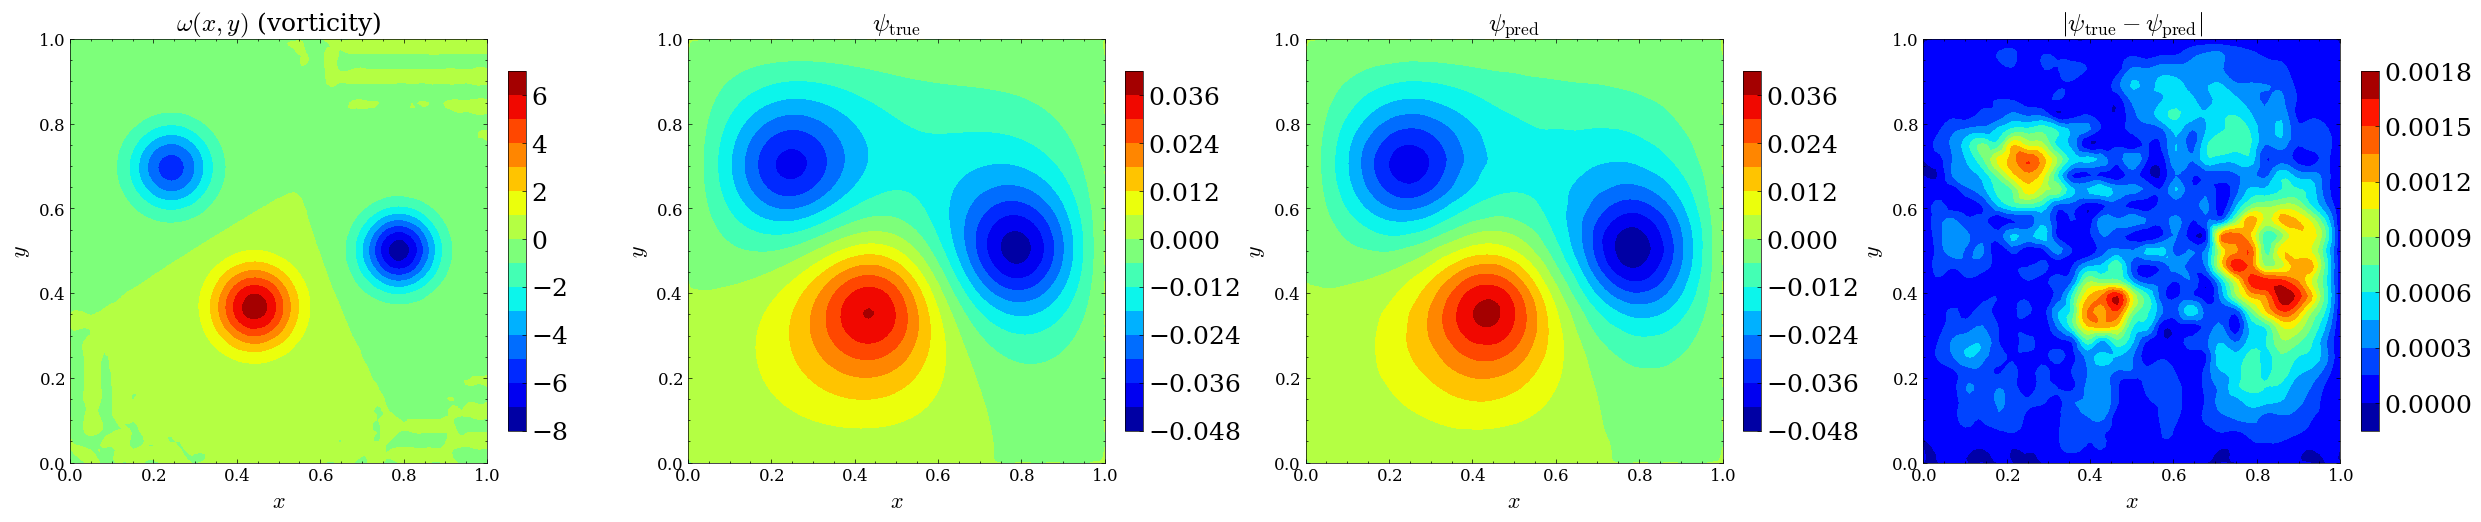

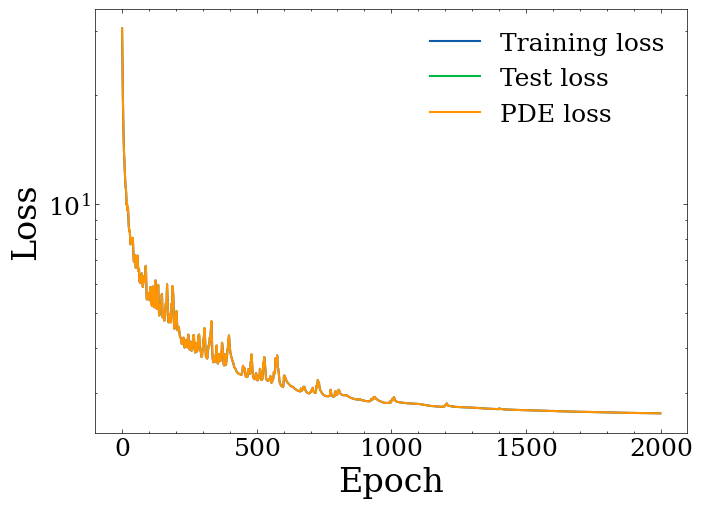

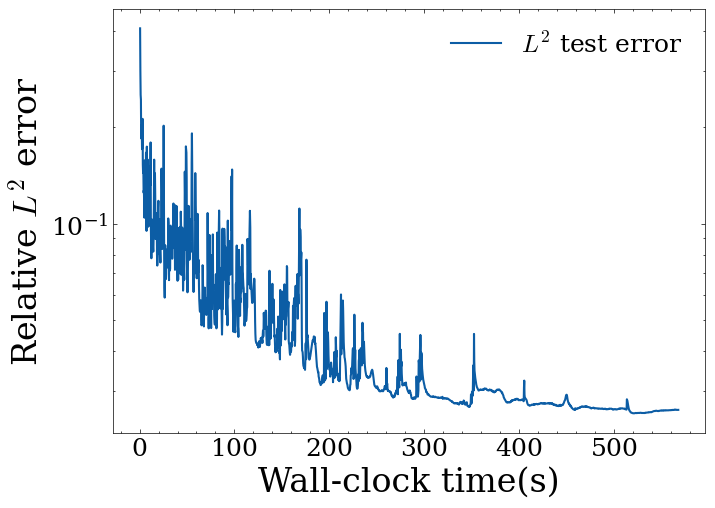

In [7]:
#######################################
# Load the trained model
#######################################
from Solvers.PIDeepONet import PIDeepONet
from torch.autograd import Variable
import matplotlib.pyplot as plt
import os
fig_dir = "figures"
os.makedirs(fig_dir, exist_ok=True)
solver = PIDeepONet.Solver(device=device, dtype=dtype)

model_trained = solver.loadModel(
    path=f'saved_models/PI{netType}_{tag}/',
    name=f'model_pideeponet_besterror'
)

#########################################
# Predict psi from omega
#########################################
x_var = Variable(x_test.to(device), requires_grad=True)
a_var = a_test.to(device)

u_pred = model_trained['u'](x_var, a_var)
u_pred = mollifier()(u_pred, x_var).detach().cpu()

print('The shape of a_test:', a_test.shape, '   # omega')
print('The shape of u_test:', u_test.shape, '   # psi_true')
print('u_pred shape:', u_pred.shape, '   # psi_pred')
print('The test l2 error (avg):', solver.getError(u_pred, u_test))

#########################################
# Plot one test example
#########################################
inx = 0

from Utils.PlotFigure import Plot

Plot.show_2d_list(
    [grid_test] * 4,
    [
        a_test[inx],
        u_test[inx],
        u_pred[inx],
        torch.abs(u_test[inx] - u_pred[inx])
    ],
    [
        r'$\omega(x,y)$ (vorticity)',
        r'$\psi_{\mathrm{true}}$',
        r'$\psi_{\mathrm{pred}}$',
        r'$|\psi_{\mathrm{true}}-\psi_{\mathrm{pred}}|$'
    ],
    lb=0.,
    save_path=f"{fig_dir}/field_prediction.png"
)

#plt.tight_layout()
#plt.savefig(f"{fig_dir}/field_prediction.png", dpi=300, bbox_inches="tight")
plt.show()

#############################################
# Show loss
#############################################
loss_saved = solver.loadLoss(
    path=f'saved_models/PI{netType}_{tag}/',
    name='loss_pideeponet'
)

Plot.show_loss(
    [
        loss_saved['loss_train'],
        loss_saved['loss_test'],
        loss_saved['loss_pde']
    ],
    [
        'Training loss',
        'Test loss',
        'PDE loss'
    ],
    save_path=f"{fig_dir}/loss_convergence.png"
)

#plt.tight_layout()
#plt.savefig(f"{fig_dir}/loss_convergence.png", dpi=300, bbox_inches="tight")
plt.show()

Plot.show_error(
    [loss_saved['time']],
    [loss_saved['error']],
    [r'$L^2$ test error'],
    save_path=f"{fig_dir}/test_error.png"
)

#plt.tight_layout()
#plt.savefig(f"{fig_dir}/test_error.png", dpi=300, bbox_inches="tight")
plt.show()

Mean L2 error: 0.02549911758862436
Median L2 error: 0.020202293060719967
Min L2 error: 0.005562583450227976
Max L2 error: 0.2080783098936081
Std L2 error: 0.020800548320714856


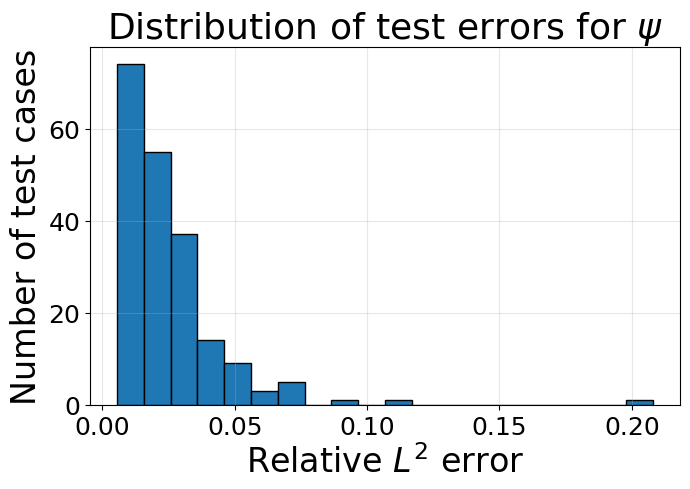

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Compute per-sample relative L2 error
err_per_case = []

for i in range(u_test.shape[0]):
    num = torch.norm(u_pred[i] - u_test[i])
    den = torch.norm(u_test[i])
    err_per_case.append((num / den).item())

err_per_case = np.array(err_per_case)

print("Mean L2 error:", np.mean(err_per_case))
print("Median L2 error:", np.median(err_per_case))
print("Min L2 error:", np.min(err_per_case))
print("Max L2 error:", np.max(err_per_case))
print("Std L2 error:", np.std(err_per_case))

#plt.figure(figsize=(7,5))
#plt.plot(np.sort(err_per_case), linewidth=2)
#plt.xlabel("Test case index (sorted)")
#plt.ylabel(r"Relative $L^2$ error")
#plt.title(r"Per-case test error for $\psi$")
#plt.grid(True, alpha=0.3)
#plt.tight_layout()
#plt.savefig("sorted_test_error.png", dpi=300, bbox_inches="tight")
#plt.show()

plt.figure(figsize=(7,5))
plt.hist(err_per_case, bins=20, edgecolor="black")
plt.xlabel(r"Relative $L^2$ error")
plt.ylabel("Number of test cases")
plt.title(r"Distribution of test errors for $\psi$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{fig_dir}/error_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

#plt.figure(figsize=(5,5))
#plt.boxplot(err_per_case, vert=True)
#plt.ylabel(r"Relative $L^2$ error")
#plt.title(r"Test error summary for $\psi$")
#plt.grid(True, alpha=0.3)
#plt.tight_layout()
#plt.savefig("boxplot_test_error.png", dpi=300, bbox_inches="tight")
#plt.show()

Easy: 137 0.009870907291769981
Medium: 168 0.020233962684869766
Hard: 36 0.048244331032037735
Easy index: 137 error: 0.009870907291769981


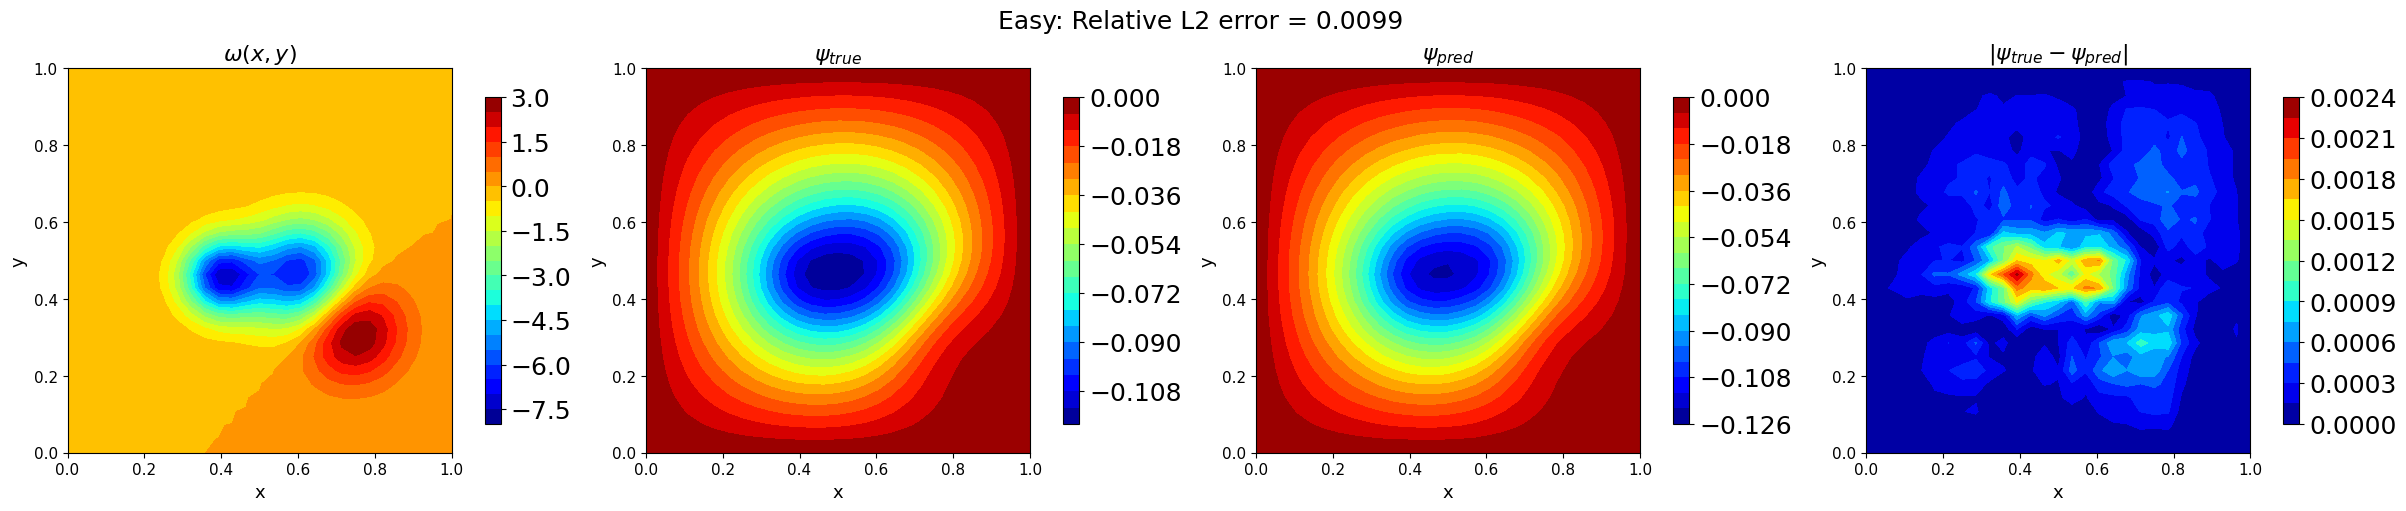

Medium index: 168 error: 0.020233962684869766


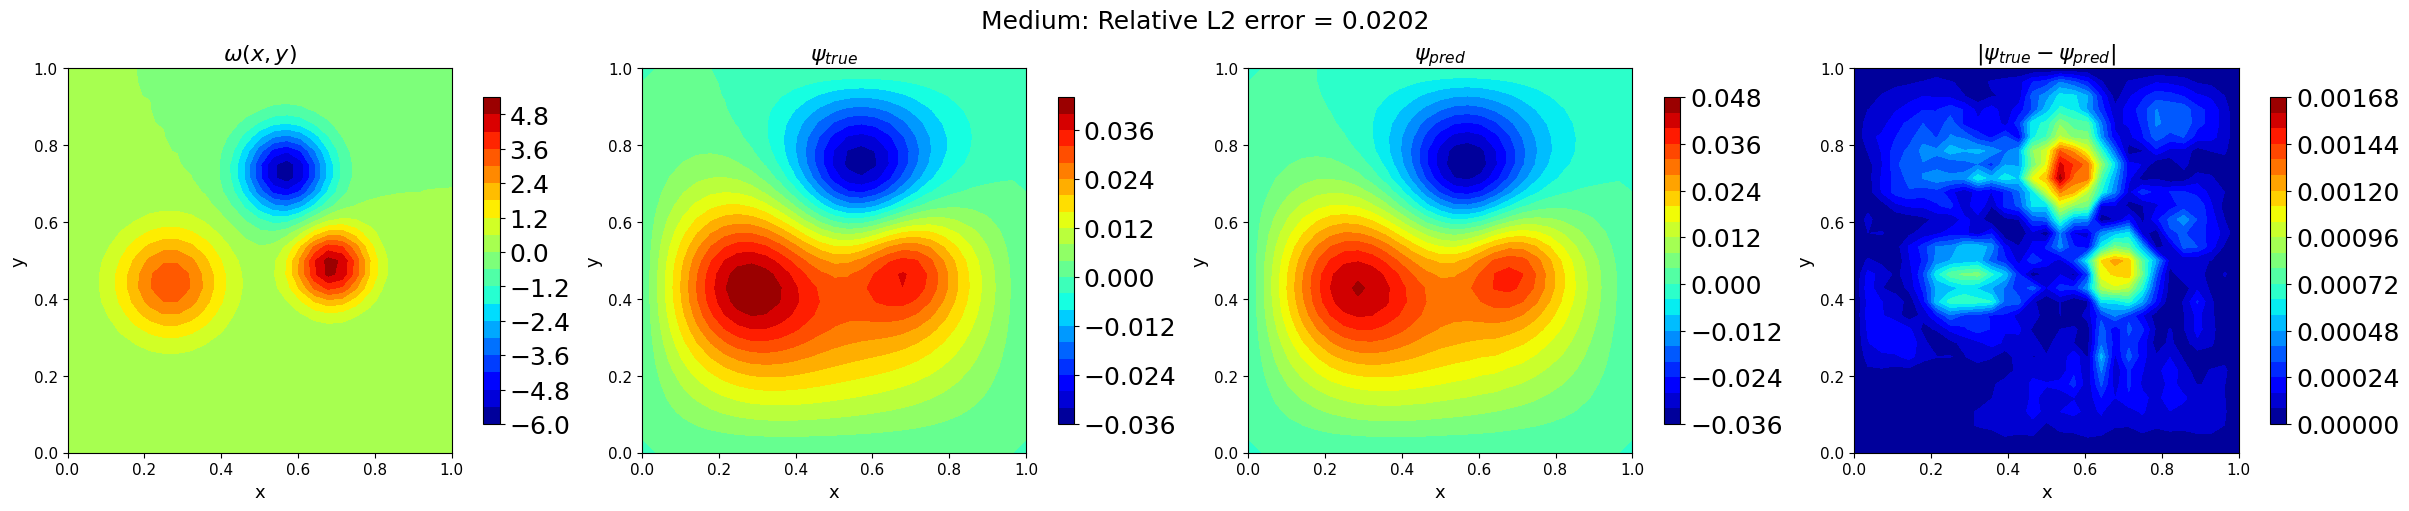

Hard index: 36 error: 0.048244331032037735


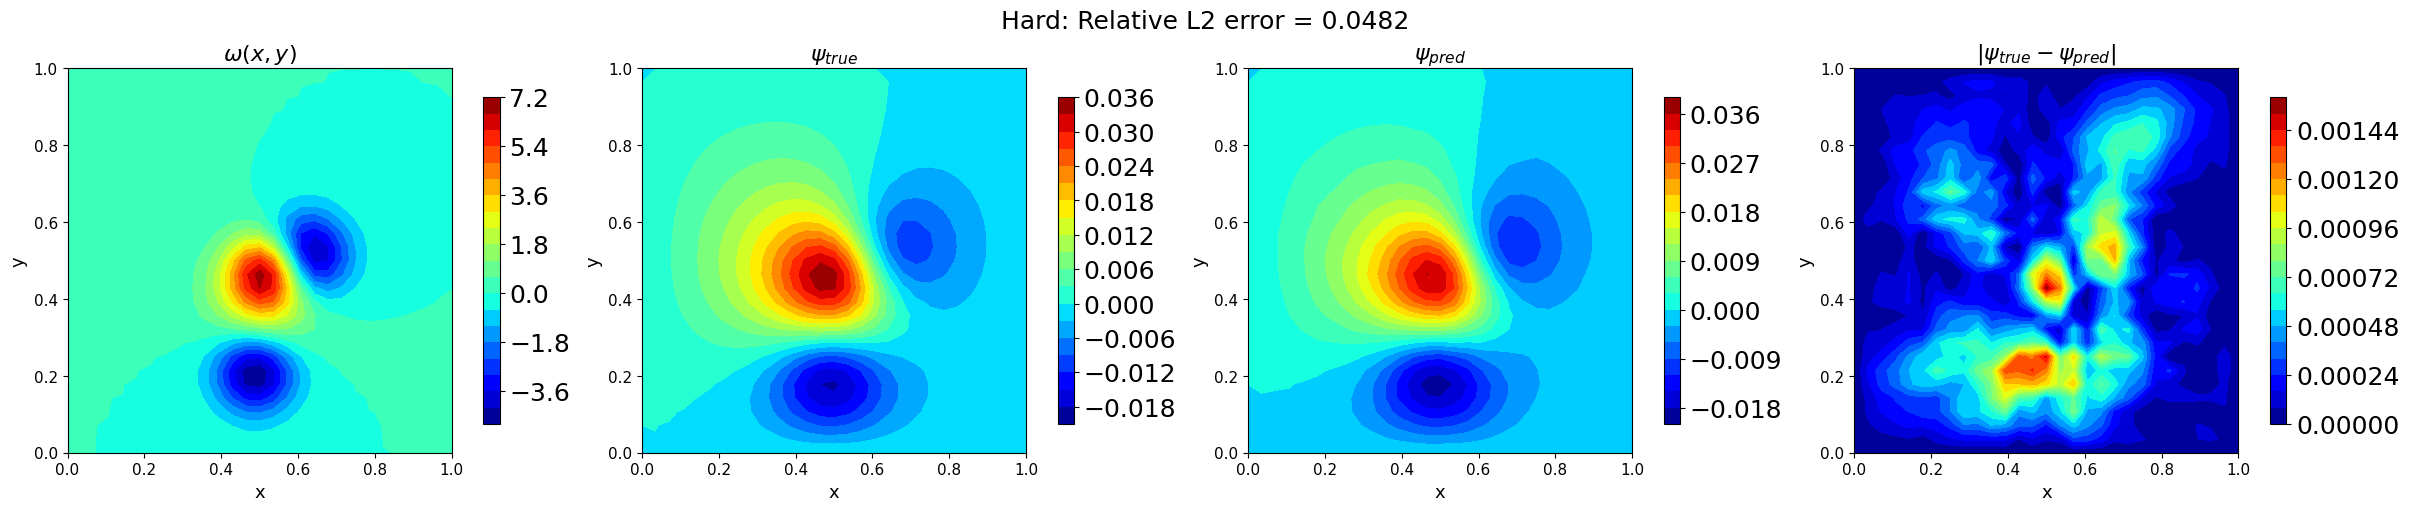

In [6]:
#########################################
# Compute per-case error (ADD THIS HERE)
#########################################
import numpy as np
import torch

err_per_case = []

for i in range(u_test.shape[0]):
    num = torch.norm(u_pred[i] - u_test[i])
    den = torch.norm(u_test[i])
    err_per_case.append((num / den).item())

err_per_case = np.array(err_per_case)

sorted_indices = np.argsort(err_per_case)

easy_idx   = sorted_indices[int(0.10 * len(sorted_indices))]
medium_idx = sorted_indices[int(0.50 * len(sorted_indices))]
hard_idx   = sorted_indices[int(0.90 * len(sorted_indices))]

print("Easy:", easy_idx, err_per_case[easy_idx])
print("Medium:", medium_idx, err_per_case[medium_idx])
print("Hard:", hard_idx, err_per_case[hard_idx])

for name, idx in zip(
    ["Easy", "Medium", "Hard"],
    [easy_idx, medium_idx, hard_idx]
):
    print(name, "index:", idx, "error:", err_per_case[idx])

    fig, axes = plt.subplots(1, 4, figsize=(24, 5), constrained_layout=True)

    fields = [
        a_test[idx].reshape(29, 29).numpy(),
        u_test[idx].reshape(29, 29).numpy(),
        u_pred[idx].reshape(29, 29).numpy(),
        torch.abs(u_test[idx] - u_pred[idx]).reshape(29, 29).numpy()
    ]

    titles = [
        r'$\omega(x,y)$',
        r'$\psi_{true}$',
        r'$\psi_{pred}$',
        r'$|\psi_{true}-\psi_{pred}|$'
    ]

    X = grid_test[:, 0].reshape(29, 29).numpy()
    Y = grid_test[:, 1].reshape(29, 29).numpy()

    for ax, field, title in zip(axes, fields, titles):
        c = ax.contourf(X, Y, field, levels=20, cmap='jet')
        ax.set_title(title, fontsize=16)
        ax.set_xlabel('x', fontsize=13)
        ax.set_ylabel('y', fontsize=13)
        ax.tick_params(labelsize=11)
        ax.set_aspect('equal')
        fig.colorbar(c, ax=ax, shrink=0.85)

    fig.suptitle(f"{name}: Relative L2 error = {err_per_case[idx]:.4f}", fontsize=18)

    plt.savefig(f"{fig_dir}/{name}_case.png", dpi=300, bbox_inches="tight")
    plt.show()